# Cluster scene: render an object table at its own positions

`ClusterSceneCatalog` draws every row of an input table once, at its own sky position, with a
bulge + disk morphology (de Vaucouleurs + exponential, the cModel decomposition of the Rubin object
table) or a single Sersic profile, and per-band magnitudes. It was written to re-simulate real cluster fields
from the Rubin DP2 object table, but any table with the right columns works. A scene holds the
cluster members only: the background sources of a simulation come from its regular galaxy catalog
(CatSim, Flagship, ...) and are lensed there, the scene supplies the foreground. This example builds a
synthetic cluster (NFW-distributed red-sequence members and a BCG) and shows the three ways to use
the catalog:

1. `draw_on_image`: render the scene onto an existing exposure outside the pipeline;
2. `lens`: apply the NFW halo to the truth catalog (members at the lens redshift are untouched);
3. `MultibandSimTask` with `galaxy_type = "cluster_scene"`: the regular pipeline path.

The last section converts the members of a real DP2 cluster with `from_dp2_objects`, renders them on the
pixel grid of the DP2 coadd and shows the residual; it only runs where the DP2 files exist.

In [1]:
%matplotlib inline

import os

import galsim
import lsst.afw.image as afwImage
import lsst.geom as geom
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import AsinhStretch, ImageNormalize, ManualInterval, make_lupton_rgb
from lsst.skymap.ringsSkyMap import RingsSkyMap, RingsSkyMapConfig

from xlens.simulator.defaults import mag_zero_defaults, noise_variance_defaults, psf_fwhm_defaults
from xlens.simulator.galaxies import ClusterSceneCatalog
from xlens.simulator.perturbation.halo import ShearHalo
from xlens.simulator.sim import MultibandSimConfig, MultibandSimTask

## A one-patch tract

The tract is placed at moderate declination on purpose: on the polar tract 0 the tangent frame of
galsim's TAN WCS is rotated relative to the LSST pixel axes.

In [2]:
config = RingsSkyMapConfig()
config.patchInnerDimensions = [1001, 1001]
config.tractOverlap = 0.0
config.patchBorder = 0
config.numRings = 5000
config.pixelScale = 0.2
config.projection = "TAN"
skymap = RingsSkyMap(config=config)
tract_id = skymap.findTract(geom.SpherePoint(10.2 * geom.degrees, -44.1 * geom.degrees)).getId()
tract_info = skymap[tract_id]
bbox = tract_info.getBBox()
pixel_scale = tract_info.getWcs().getPixelScale().asArcseconds()
box_arcsec = bbox.getWidth() * pixel_scale
print(f"tract {tract_id}: {bbox.getWidth()} x {bbox.getHeight()} pixels = {box_arcsec / 60:.1f} arcmin")

tract 4840637: 1001 x 1001 pixels = 3.3 arcmin


## A synthetic cluster scene

Columns of a scene table: a position (`dx`, `dy` in arcsec from the tract centre, or `ra`, `dec`),
`redshift`, a morphology and `{survey}_{band}` AB magnitudes (`is_point_source` would mark stars).
The bulge + disk morphology used here has the half-light ellipse of each component (`bulge_r50_major`,
`bulge_r50_minor`, `bulge_theta`, and the same for `disk_`; arcsec and degrees from the pixel x axis)
and a per-band bulge fraction `{survey}_{band}_bulge_frac`; a single Sersic profile takes `sersic_n`,
`r50_major`, `r50_minor`, `theta` instead. Members follow a projected NFW profile, with a red-sequence
colour and bulge-dominated light for the bright ones.

In [3]:
Z_CLUSTER = 0.3
MAG_ZERO = mag_zero_defaults["lsst"]
rng = np.random.default_rng(7)


def projected_nfw(x):
    """Shape of the projected NFW profile as a function of R / r_s."""
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, 1.0 / 3.0)
    m = x > 1
    s = np.sqrt(x[m] ** 2 - 1)
    out[m] = (1 - 2 / s * np.arctan(np.sqrt((x[m] - 1) / (x[m] + 1)))) / (x[m] ** 2 - 1)
    m = x < 1
    s = np.sqrt(1 - x[m] ** 2)
    out[m] = (1 - 2 / s * np.arctanh(np.sqrt((1 - x[m]) / (1 + x[m])))) / (x[m] ** 2 - 1)
    return out


def sample_nfw_positions(num, r_s, half_box):
    """Rejection-sample tangent-plane positions (arcsec) from the projected NFW."""
    out = []
    peak = projected_nfw(0.02)
    while len(out) < num:
        x, y = rng.uniform(-half_box, half_box, 2 * num), rng.uniform(-half_box, half_box, 2 * num)
        p = projected_nfw(np.maximum(np.hypot(x, y), 0.02 * r_s) / r_s) / peak
        keep = rng.uniform(size=2 * num) < p
        out += list(zip(x[keep], y[keep]))
    return np.array(out[:num])


def sample_magnitudes(num, m_bright, m_faint, slope=0.3):
    """Magnitudes with dN/dm proportional to 10**(slope * m)."""
    u = rng.uniform(size=num)
    a, b = 10 ** (slope * m_bright), 10 ** (slope * m_faint)
    return np.log10(a + u * (b - a)) / slope


def make_scene(half_box, n_mem=150):
    # per row: dx, dy, i mag, bulge fraction, disk (a, b, theta), bulge (a, b, theta), g-r, r-i
    rows = []
    # brightest cluster galaxy at the centre: bulge-dominated, with a faint extended disk
    rows.append((0.0, 0.0, 17.5, 0.9, 5.0, 4.0, 20.0, 2.5, 2.0, 20.0, 1.45, 0.6))
    # members: NFW positions, red sequence, bulge-dominated light for the bright ones
    pos = sample_nfw_positions(n_mem, r_s=40.0, half_box=half_box)
    mag = sample_magnitudes(n_mem, 18.5, 25.0)
    for (x, y), m in zip(pos, mag):
        disk_r50 = 0.4 * 10 ** (-0.2 * (m - 22.0)) * rng.lognormal(0.0, 0.3)
        bulge_r50 = 0.5 * disk_r50 * rng.lognormal(0.0, 0.2)
        q_disk, q_bulge = rng.uniform(0.3, 1.0), rng.uniform(0.6, 1.0)
        theta = rng.uniform(-90, 90)
        frac = np.clip(rng.normal(0.8 if m < 21.0 else 0.35, 0.15), 0.0, 1.0)
        rows.append((x, y, m, frac, disk_r50, disk_r50 * q_disk, theta,
                     bulge_r50, bulge_r50 * q_bulge, theta + rng.normal(0.0, 10.0), 1.4, 0.55))
    rows = np.array(rows, dtype=float)
    table = {
        "dx": rows[:, 0],
        "dy": rows[:, 1],
        "redshift": np.full(len(rows), Z_CLUSTER),
        "disk_r50_major": rows[:, 4],
        "disk_r50_minor": rows[:, 5],
        "disk_theta": rows[:, 6],
        "bulge_r50_major": rows[:, 7],
        "bulge_r50_minor": rows[:, 8],
        "bulge_theta": rows[:, 9],
    }
    mag_i = rows[:, 2]
    table["lsst_i"] = mag_i
    table["lsst_r"] = mag_i + rows[:, 11]
    table["lsst_g"] = table["lsst_r"] + rows[:, 10]
    # the bulge is redder than the disk, so its fraction of the light drops towards the blue
    frac = rows[:, 3]
    table["lsst_i_bulge_frac"] = frac
    table["lsst_r_bulge_frac"] = frac
    table["lsst_g_bulge_frac"] = np.clip(frac - 0.1, 0.0, 1.0)
    return table


scene_table = make_scene(half_box=0.5 * box_arcsec)
print({name: np.round(values[:3], 3) for name, values in scene_table.items()})
print(len(scene_table["dx"]), "members")

{'dx': array([0.   , 0.911, 2.826]), 'dy': array([  0.   , -23.732, -64.703]), 'redshift': array([0.3, 0.3, 0.3]), 'disk_r50_major': array([5.   , 1.034, 0.258]), 'disk_r50_minor': array([4.   , 0.406, 0.247]), 'disk_theta': array([ 20.   ,  75.619, -20.718]), 'bulge_r50_major': array([2.5  , 0.451, 0.131]), 'bulge_r50_minor': array([2.   , 0.386, 0.12 ]), 'bulge_theta': array([ 20.   ,  68.918, -26.368]), 'lsst_i': array([17.5  , 20.329, 22.508]), 'lsst_r': array([18.1  , 20.879, 23.058]), 'lsst_g': array([19.55 , 22.279, 24.458]), 'lsst_i_bulge_frac': array([0.9 , 0.8 , 0.22]), 'lsst_r_bulge_frac': array([0.9 , 0.8 , 0.22]), 'lsst_g_bulge_frac': array([0.8 , 0.7 , 0.12])}
151 members


## The catalog and its truth table

In [4]:
catalog = ClusterSceneCatalog(scene=scene_table, tract_info=tract_info)
print(len(catalog), "members; truth columns:", catalog.data.dtype.names)
# dx, dy are tangent-plane offsets from the tract centre; ra, dec follow from the tract WCS
# ``hlr`` is the circularised disk radius and ``angles`` the disk position angle
print(catalog.data[["dx", "dy", "ra", "dec", "hlr", "angles"]][:3])

151 members; truth columns: ('indices', 'redshift', 'angles', 'gamma1', 'gamma2', 'kappa', 'dx', 'dy', 'ra', 'dec', 'prelensed_ra', 'prelensed_dec', 'has_finite_shear', 'hlr', 'disk_r50_major', 'disk_r50_minor', 'disk_theta', 'bulge_r50_major', 'bulge_r50_minor', 'bulge_theta', 'lsst_i', 'lsst_r', 'lsst_g', 'lsst_i_bulge_frac', 'lsst_r_bulge_frac', 'lsst_g_bulge_frac')
[(0.        ,   0.        , 10.22271715, -44.10917816, 4.47213595,  0.34906585)
 (0.91056144, -23.73153394, 10.22236484, -44.11577026, 0.64795594,  1.31980545)
 (2.82635285, -64.70312665, 10.22162339, -44.12715125, 0.25234238, -0.36160509)]


## Render onto an exposure

`draw_on_image` adds the scene to an image in place with the same stamp logic as the pipeline. An
`Exposure` supplies the WCS (and the PSF, when it has one); here the PSF is passed explicitly.

In [5]:
def render(catalog, band, psf_fwhm=None):
    exposure = afwImage.ExposureF(bbox)
    exposure.setWcs(tract_info.getWcs())
    psf = galsim.Moffat(fwhm=psf_fwhm or psf_fwhm_defaults[band]["lsst"], beta=2.5)
    truth = catalog.draw_on_image(exposure, band=band, mag_zero=MAG_ZERO, psf_obj=psf)
    return exposure.image.array, truth


images = {}
for band in ("g", "r", "i"):
    images[band], truth = render(catalog, band)
    print(f"{band}: drew {truth['drawn'].sum()} of {len(truth)} objects, total flux {images[band].sum():.3e}")

expected = np.sum(10 ** ((MAG_ZERO - catalog.data["lsst_i"]) / 2.5))
print(f"i-band flux in the image / catalog: {images['i'].sum() / expected:.4f}")

g: drew 151 of 151 objects, total flux 3.657e+04
r: drew 151 of 151 objects, total flux 1.353e+05


i: drew 151 of 151 objects, total flux 2.291e+05
i-band flux in the image / catalog: 0.9920


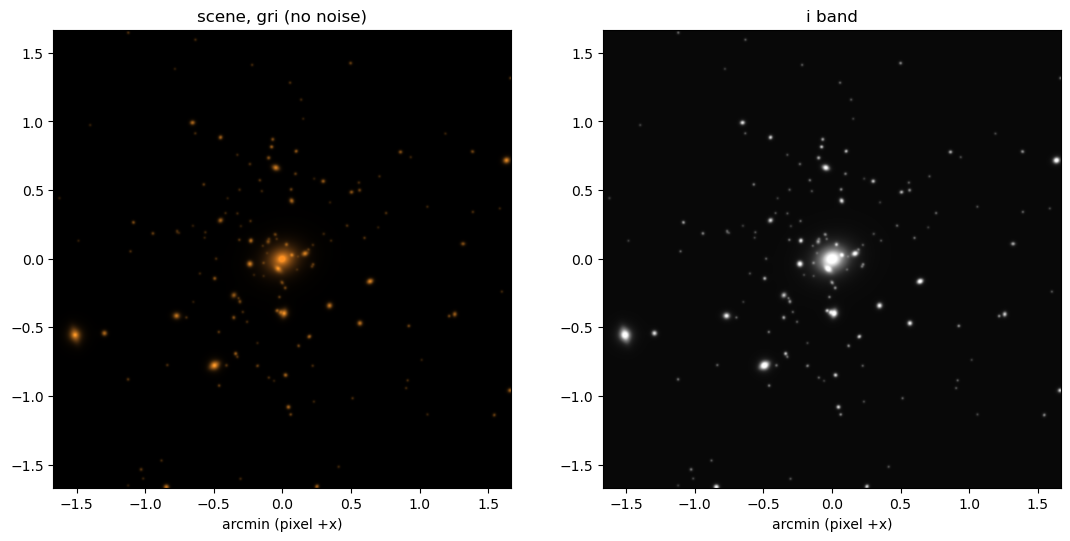

In [6]:
extent = np.array([-0.5, 0.5, -0.5, 0.5]) * box_arcsec / 60
sigma = {b: np.sqrt(noise_variance_defaults[b]["lsst"]) for b in ("g", "r", "i")}
with np.errstate(invalid="ignore"):  # noiseless zeros in the RGB normalisation
    rgb = make_lupton_rgb(images["i"], images["r"], images["g"], Q=8, stretch=30 * sigma["i"])
fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
axes[0].imshow(rgb, origin="lower", extent=extent)
axes[0].set_title("scene, gri (no noise)")
axes[1].imshow(
    images["i"], origin="lower", cmap="Greys_r", extent=extent,
    norm=ImageNormalize(images["i"], interval=ManualInterval(-0.5, 60), stretch=AsinhStretch(0.1)),
)
axes[1].set_title("i band")
for ax in axes:
    ax.set_xlabel("arcmin (pixel +x)")
plt.show()
plt.close()

## Lensing by the cluster halo

`lens` fills the shear columns of the truth catalog the way `CatalogHaloTask` does. The members sit at
the lens redshift, so the halo leaves them untouched; a source behind the cluster in the same table
would be sheared, but in a simulation the background galaxies come from the regular galaxy catalog
and get their shear there.

In [7]:
halo = ShearHalo(mass=5e14, conc=4.0, z_lens=Z_CLUSTER)
dx_before = catalog.data["dx"].copy()
catalog.lens(shear_obj=halo)
data = catalog.data
print("lensed:", catalog.lensed, "; max |gamma|, |kappa| of the members:",
      np.abs(data[["gamma1", "gamma2"]].tolist()).max(), np.abs(data["kappa"]).max())
assert np.all(data["gamma1"] == 0) and np.all(data["kappa"] == 0)
assert np.array_equal(data["dx"], dx_before)

# the same halo does shear a source behind the cluster (here a single-Sersic scene row)
probe = ClusterSceneCatalog(
    scene={"dx": [30.0], "dy": [0.0], "redshift": [1.0], "sersic_n": [1.0], "r50_major": [0.5],
           "r50_minor": [0.5], "theta": [0.0], "lsst_i": [23.0]},
    tract_info=tract_info,
)
probe.lens(shear_obj=halo)
print("a z = 1 source 30 arcsec from the centre: gamma1 = %.4f, gamma2 = %.4f, kappa = %.4f"
      % (probe.data["gamma1"][0], probe.data["gamma2"][0], probe.data["kappa"][0]))

lensed: True ; max |gamma|, |kappa| of the members: 0.0 0.0


a z = 1 source 30 arcsec from the centre: gamma1 = -0.1045, gamma2 = 0.0000, kappa = 0.2286


## The pipeline path

With `galaxy_type = "cluster_scene"` the simulation task renders the lensed truth catalog, adds
noise and returns a calibrated exposure, exactly as for the other galaxy catalogs. Subtracting a
noiseless `draw_on_image` render of the same lensed catalog leaves pure noise.

residual std 0.595 vs noise std 0.595; residual mean -0.0008


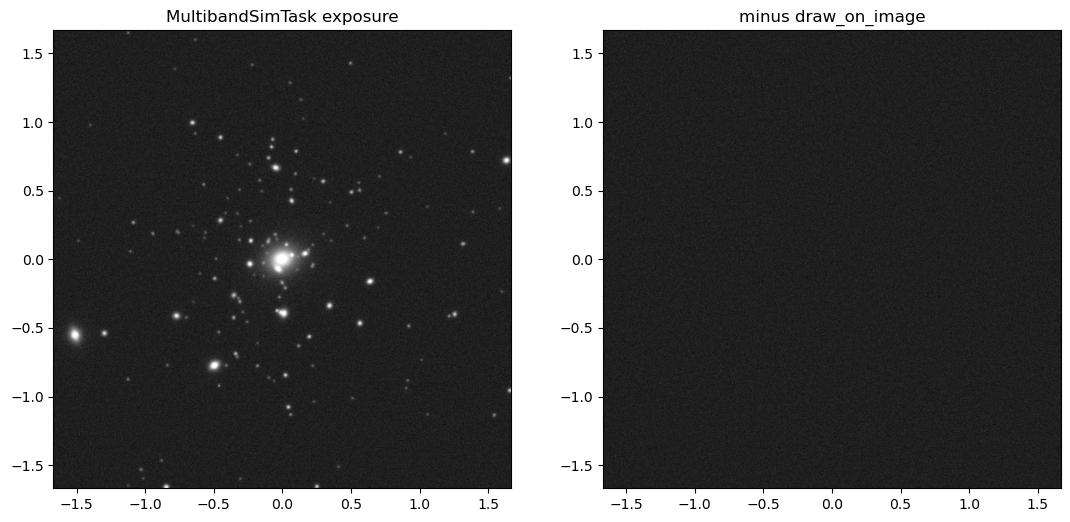

In [8]:
config = MultibandSimConfig()
config.galaxy_type = "cluster_scene"
config.survey_name = "lsst"
config.draw_image_noise = True
sim_task = MultibandSimTask(config=config)
exposure = sim_task.run(
    tract_info=tract_info, patch_id=0, band="i", seed=1, truthCatalog=catalog.data
).simExposure
sim_array = exposure.image.array

noiseless, _ = render(catalog, "i")
residual = sim_array - noiseless
print(f"residual std {residual.std():.3f} vs noise std {sigma['i']:.3f}; residual mean {residual.mean():+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
for ax, image, title in zip(axes, [sim_array, residual], ["MultibandSimTask exposure", "minus draw_on_image"]):
    ax.imshow(
        image, origin="lower", cmap="Greys_r", extent=extent,
        norm=ImageNormalize(image, interval=ManualInterval(-2, 60), stretch=AsinhStretch(0.1)),
    )
    ax.set_title(title)
plt.show()
plt.close()
assert abs(residual.std() / sigma["i"] - 1) < 0.05

## A real DP2 cluster field

`from_dp2_objects` maps the Rubin object-table columns: `coord_ra`/`coord_dec`, the cModel
decomposition (`{band}_cModel_dev_*` and `{band}_cModel_exp_*` half-light ellipses of the morphology
band, `{band}_cModel_fracDev` per band), `{band}_cModelFlux` in nJy (PSF flux for point sources),
`refExtendedness` and a photo-z column; `morphology="sersic"` uses the multi-band Sersic fit
instead. Only the cluster members are kept: galaxies whose photo-z lies within
0.05 (1 + z) of the cluster redshift. To compare with the data, the scene is rendered on the pixel grid of the DP2
`deep_coadd` tiles themselves: the tiles are read with `afw`, which gives the tract WCS and each
tile's origin in tract pixels, and the PSF is taken from the tile's grid of per-cell PSF stamps at
the cluster position. Any object with `getWcs()` and `getBBox()` defines the pixel frame of a
scene, so an `Exposure` of the cut serves as `tract_info`. This section needs a cutout of the DP2
object table and the coadd tiles on disk; it is skipped otherwise.

In [9]:
dp2_file = os.environ.get(
    "DP2_SCENE_FILE", "/pscratch/sd/z/zchusre/swirl/dp2_clusters/data/dp2_ACTJ0040.8-4408_RM19_r10arcmin.parquet"
)
dp2_coadd_dir = os.environ.get(
    "DP2_COADD_DIR",
    "/global/cfs/cdirs/lsst/shared/rubin/rucio/dp2/LSSTCam/runs/DRP/DP2/v30_0_8/DM-55060/"
    "deep_coadd_rewrite/20260618T031503Z/deep_coadd/2877",
)
ra_cl, dec_cl, z_cl = 10.208103, -44.133697, 0.35
bands_dp2 = ("g", "r", "i")
half_cut = 750  # pixels: a 5 x 5 arcmin cut
have_dp2 = os.path.isfile(dp2_file) and os.path.isdir(dp2_coadd_dir)
if have_dp2:
    import glob
    import logging

    import pandas as pd
    from astropy.io import fits

    logging.getLogger("lsst.afw.image.MaskedImageFitsReader").setLevel(logging.ERROR)
    try:  # the reader logs through lsst.log when it is not routed to Python logging
        import lsst.log

        lsst.log.setLevel("lsst.afw.image.MaskedImageFitsReader", lsst.log.ERROR)
    except ImportError:
        pass
    objects = pd.read_parquet(dp2_file)
    # cluster members: galaxies with a photo-z inside the cluster window (stars are excluded
    # by the extendedness cut; the same cuts could be passed as select_observable limits)
    members = objects[
        (objects.refExtendedness > 0.5) & ((objects.bpz_z_best - z_cl).abs() < 0.05 * (1 + z_cl))
    ]
    # tiles overlapping the cut: the patches of the objects within its radius
    sep = np.hypot(
        (objects.coord_ra - ra_cl) * np.cos(np.radians(dec_cl)), objects.coord_dec - dec_cl
    ) * 3600
    patches = sorted(objects.loc[sep < half_cut * 0.2 * np.sqrt(2), "patch"].dropna().astype(int).unique())
    tile_files = {(b, p): glob.glob(f"{dp2_coadd_dir}/{p}/{b}/*.fits")[0] for b in bands_dp2 for p in patches}
    tiles = {key: afwImage.ExposureF(fn) for key, fn in tile_files.items()}
    coadd_wcs = tiles[("i", patches[0])].getWcs()
    centre = coadd_wcs.skyToPixel(geom.SpherePoint(ra_cl * geom.degrees, dec_cl * geom.degrees))
    cut = geom.Box2I(
        geom.Point2I(int(round(centre.getX())) - half_cut, int(round(centre.getY())) - half_cut),
        geom.Extent2I(2 * half_cut, 2 * half_cut),
    )
    frame = afwImage.ExposureF(cut)
    frame.setWcs(coadd_wcs)
    real_scene = ClusterSceneCatalog.from_dp2_objects(
        members, tract_info=frame, bands=bands_dp2, default_redshift=z_cl,
        select_observable=["lsst_i"], select_upper_limit=[25.0],
    )
    print(f"tiles {patches}; cluster at tract pixel ({centre.getX():.1f}, {centre.getY():.1f}); cut {cut}")
    print(f"{len(members)} member candidates of {len(objects)} objects; {len(real_scene)} with i < 25 in the scene")
else:
    print("DP2 cutout or coadd tiles not available - section skipped")

tiles [np.int64(34), np.int64(35)]; cluster at tract pixel (14500.2, 10509.7); cut (minimum=(13750, 9760), maximum=(15249, 11259))
3722 member candidates of 30003 objects; 2967 with i < 25 in the scene


In [10]:
def paste(dst, dst_box, src, src_box):
    """Copy the overlap of two arrays given their bounding boxes in tract pixels."""
    overlap = geom.Box2I(dst_box)
    overlap.clip(src_box)
    if overlap.isEmpty():
        return
    dy, dx = overlap.getMinY() - dst_box.getMinY(), overlap.getMinX() - dst_box.getMinX()
    sy, sx = overlap.getMinY() - src_box.getMinY(), overlap.getMinX() - src_box.getMinX()
    h, w = overlap.getHeight(), overlap.getWidth()
    dst[dy : dy + h, dx : dx + w] = src[sy : sy + h, sx : sx + w]


if have_dp2:
    NJY_TO_COUNTS = 10 ** (0.4 * (MAG_ZERO - 31.4))  # DP2 pixels are nJy; the scene uses mag_zero 30
    real, real_var, model = {}, {}, {}
    for band in bands_dp2:
        image = np.full((2 * half_cut, 2 * half_cut), np.nan, dtype=np.float32)
        variance = np.full_like(image, np.nan)
        for patch in patches:
            tile = tiles[(band, patch)]
            paste(image, cut, tile.image.array, tile.getBBox())
            paste(variance, cut, tile.variance.array, tile.getBBox())
        real[band] = np.nan_to_num(image) * NJY_TO_COUNTS
        real_var[band] = variance * NJY_TO_COUNTS**2
        # PSF of the cell that holds the cluster, from the tile's grid of PSF stamps
        tile_key = next((band, p) for p in patches if tiles[(band, p)].getBBox().contains(geom.Point2I(centre)))
        tile_box = tiles[tile_key].getBBox()
        with fits.open(tile_files[tile_key]) as hdus:
            psf_cells = hdus["PSF"].data
        cell = tile_box.getWidth() // psf_cells.shape[1]
        stamp = psf_cells[
            (int(centre.getY()) - tile_box.getMinY()) // cell, (int(centre.getX()) - tile_box.getMinX()) // cell
        ]
        psf = galsim.InterpolatedImage(galsim.Image(stamp.astype(float)), scale=0.2, flux=1.0)
        exposure = afwImage.ExposureF(cut)
        exposure.setWcs(coadd_wcs)
        # the PSF stamp is already pixel-sampled, so draw without a second pixel convolution
        real_scene.draw_on_image(exposure, band=band, mag_zero=MAG_ZERO, psf_obj=psf, draw_method="no_pixel")
        model[band] = exposure.image.array.copy()
        residual = real[band] - model[band]
        noise = np.sqrt(np.nanmedian(real_var[band]))
        print(
            f"{band}: members / total flux in the cut {model[band].sum() / real[band].sum():.3f};"
            f" residual std {residual.std():.3f} vs data noise {noise:.3f} counts"
        )

g: members / total flux in the cut 0.232; residual std 21.750 vs data noise 0.414 counts


r: members / total flux in the cut 0.366; residual std 38.465 vs data noise 0.785 counts


i: members / total flux in the cut 0.412; residual std 47.923 vs data noise 0.678 counts


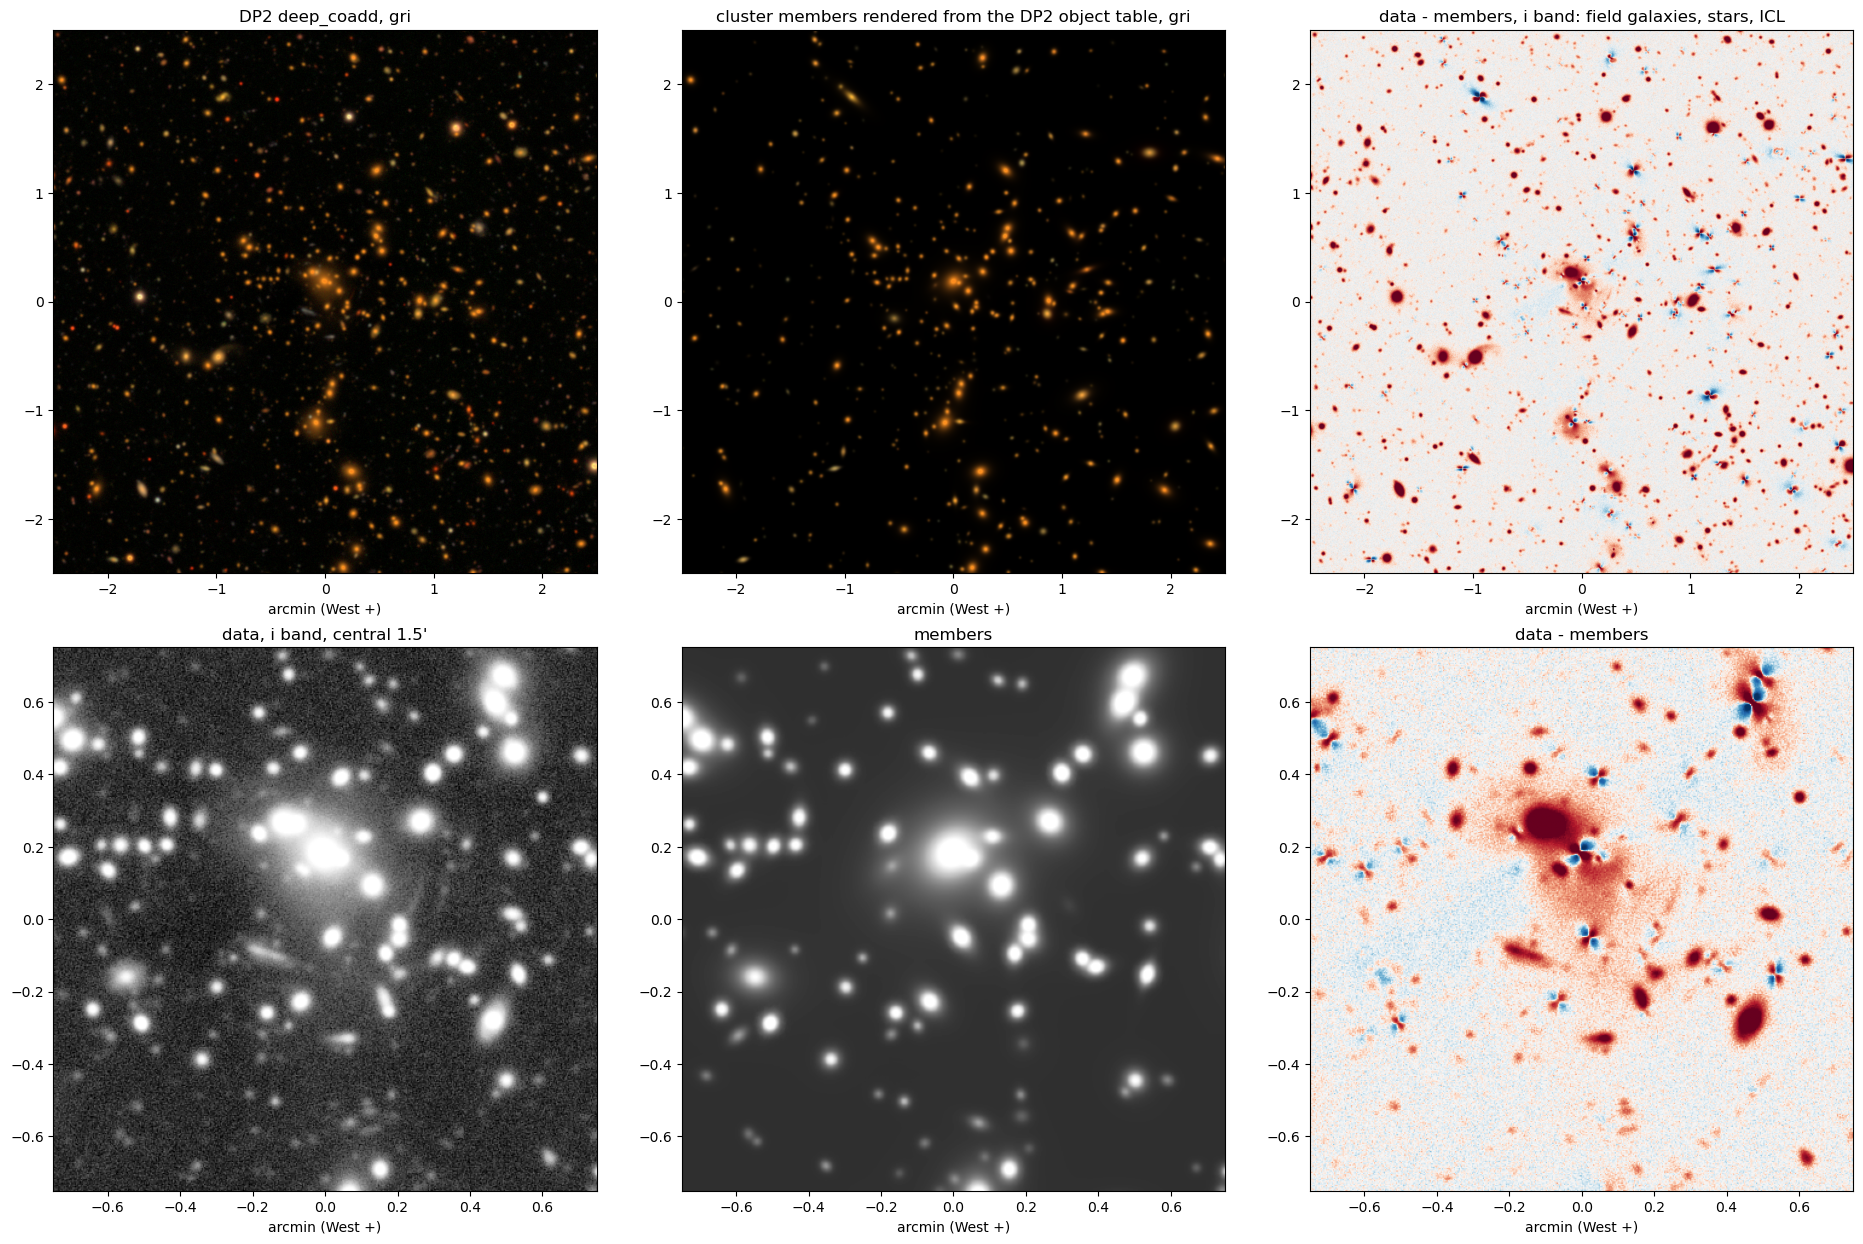

In [11]:
if have_dp2:
    noise_i = np.sqrt(np.nanmedian(real_var["i"]))
    extent_dp2 = [-2.5, 2.5, -2.5, 2.5]
    with np.errstate(invalid="ignore"):
        rgb_real = make_lupton_rgb(real["i"], real["r"], real["g"], Q=8, stretch=30 * noise_i)
        rgb_model = make_lupton_rgb(model["i"], model["r"], model["g"], Q=8, stretch=30 * noise_i)
    residual_i = real["i"] - model["i"]

    def show_residual(ax, image, extent):
        """Symmetric arcsinh stretch in units of the noise, white at zero."""
        stretched = np.arcsinh(image / (3 * noise_i))
        limit = np.arcsinh(25 / 3)
        ax.imshow(stretched, origin="lower", cmap="RdBu_r", vmin=-limit, vmax=limit, extent=extent)

    fig, axes = plt.subplots(2, 3, figsize=(19, 12.5))
    axes[0, 0].imshow(rgb_real, origin="lower", extent=extent_dp2)
    axes[0, 0].set_title("DP2 deep_coadd, gri")
    axes[0, 1].imshow(rgb_model, origin="lower", extent=extent_dp2)
    axes[0, 1].set_title("cluster members rendered from the DP2 object table, gri")
    show_residual(axes[0, 2], residual_i, extent_dp2)
    axes[0, 2].set_title("data - members, i band: field galaxies, stars, ICL")
    zoom = slice(half_cut - 225, half_cut + 225)  # central 1.5 arcmin
    extent_zoom = [-0.75, 0.75, -0.75, 0.75]
    for ax, image, title in zip(
        axes[1, :2], [real["i"][zoom, zoom], model["i"][zoom, zoom]], ["data, i band, central 1.5'", "members"]
    ):
        ax.imshow(
            image, origin="lower", cmap="Greys_r", extent=extent_zoom,
            norm=ImageNormalize(image, interval=ManualInterval(-3 * noise_i, 60 * noise_i), stretch=AsinhStretch(0.1)),
        )
        ax.set_title(title)
    show_residual(axes[1, 2], residual_i[zoom, zoom], extent_zoom)
    axes[1, 2].set_title("data - members")
    for ax in axes.ravel():
        ax.set_xlabel("arcmin (West +)")
    plt.tight_layout()
    plt.show()
    plt.close()